In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import csv
import os
from pathlib import Path


### Read data

In [3]:
def read_csv(file_name: str) -> pd.DataFrame :
    """
     summary

    """
    try: 
        dir_folder = Path().cwd().parent.parent
        print(dir_folder)
        file_path = dir_folder / 'data'
        print(file_path)
        df= pd.read_csv(os.path.join(file_path,file_name))
        return df
        
    except FileNotFoundError:
        print(f" Error : The file at {file_name} was not found.")
        raise
    except Exception as e:
        print(f'An error occured: {e}')
        
df = read_csv('a1_IMDB_Dataset.csv')

c:\Abdelouaheb\perso\Data_science_2024_projects\2025\DeepLearning_project
c:\Abdelouaheb\perso\Data_science_2024_projects\2025\DeepLearning_project\data


### Data preprocessing

In [4]:
df.head(5)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
df.groupby('sentiment').count()

,review
sentiment,
negative,25000
positive,25000


In [7]:
df['char_count']= df['review'].str.len() # Count number of character in each column


In [8]:
df.head()

,review,sentiment,char_count
0,One of the other reviewers has mentioned that ...,positive,1761
1,A wonderful little production. <br /><br />The...,positive,998
2,I thought this was a wonderful way to spend ti...,positive,926
3,Basically there's a family where a little boy ...,negative,748
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317


In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
char_count,50000.0,1309.43102,989.728014,32.0,699.0,970.0,1590.25,13704.0


### WordMap analysis

In [ ]:
#! pip install wordcloud

In [10]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer 
from wordcloud import WordCloud
import re
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to C:\Users\ASUS
[nltk_data]     TUF\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\ASUS
[nltk_data]     TUF\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\ASUS
[nltk_data]     TUF\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [11]:
df['sentiment'].unique()

array(['positive', 'negative'], dtype=object)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   review      50000 non-null  object
 1   sentiment   50000 non-null  object
 2   char_count  50000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


In [13]:
lm= WordNetLemmatizer()

def text_transformation(data: pd.DataFrame) -> list:
        corpus = []
        for item in data:
            new_item = re.sub('[^a-zA-Z]',' ',str(item))
            new_item = new_item.lower()
            new_item = new_item.split()
            new_item = [lm.lemmatize(word) for word in new_item if word not in set(stopwords.words('english'))]
            corpus.append(' '.join(str(x) for x in new_item))
        return corpus

def word_cloud_generate(category : str) -> plt:
    df_test= df[df['sentiment']==category][['review']]
    df_test['text']= df_test['text'].astype(str)
    df_test['text']= df_test['text'].str.lower()
    corpus = text_transformation(df_test['review'])
    word_cloud = ''
    for row in corpus :
        for word in row:
            word_cloud += "".join(word)
    wordcloud = WordCloud(width = 1000, height = 500,background_color ='white',min_font_size = 10).generate(word_cloud)
    
    return wordcloud

In [ ]:
# Get unique categories
categories = df['review'].unique()
n = len(categories)

# Set up subplots grid (auto-adjusted rows/cols)
cols = 2
rows = (n + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, 6 * rows))
axes = axes.flatten()  # flatten in case of 1D row

for i, cat in enumerate(categories):
    wc = word_cloud_generate(cat)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f"review: {cat}", fontsize=14)
    axes[i].axis('off')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

### RNN 

#### Data structure

In [16]:
vpcap_size = 1000
dim = 16
max_length = 120
trunc_type = 'post'
padding_type = 'post'
oov_tok = '<OOV>'
training_portion = .8

In [65]:
stop_words = set(stopwords.words('english'))
sentences = []
labels = []

def df_remove_stopwords(text: str) -> str:
    
    for word in stop_words:
        token= ' '+ word + ' '
        text = text.replace(token,' ')
    return text

labels = df['sentiment'].to_list()
sentences = df['review'].astype(str).apply(df_remove_stopwords).to_list()
    

In [66]:
len(labels)
len(sentences)

50000

In [67]:
labels

['positive',
 'positive',
 'positive',
 'negative',
 'positive',
 'positive',
 'positive',
 'negative',
 'negative',
 'positive',
 'negative',
 'negative',
 'negative',
 'negative',
 'positive',
 'negative',
 'positive',
 'negative',
 'positive',
 'negative',
 'positive',
 'negative',
 'positive',
 'negative',
 'negative',
 'positive',
 'positive',
 'negative',
 'negative',
 'positive',
 'positive',
 'positive',
 'negative',
 'positive',
 'negative',
 'negative',
 'negative',
 'negative',
 'positive',
 'negative',
 'negative',
 'positive',
 'negative',
 'negative',
 'positive',
 'positive',
 'negative',
 'negative',
 'positive',
 'negative',
 'positive',
 'positive',
 'positive',
 'positive',
 'negative',
 'negative',
 'negative',
 'negative',
 'positive',
 'positive',
 'negative',
 'negative',
 'positive',
 'negative',
 'negative',
 'positive',
 'negative',
 'negative',
 'negative',
 'negative',
 'negative',
 'negative',
 'positive',
 'positive',
 'negative',
 'positive',
 'positive',

In [68]:
sentences

["One reviewers mentioned watching 1 Oz episode hooked. They right, exactly happened me.<br /><br />The first thing struck Oz brutality unflinching scenes violence, set right word GO. Trust me, show faint hearted timid. This show pulls punches regards drugs, sex violence. Its hardcore, classic use word.<br /><br />It called OZ nickname given Oswald Maximum Security State Penitentary. It focuses mainly Emerald City, experimental section prison cells glass fronts face inwards, privacy high agenda. Em City home many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish more....so scuffles, death stares, dodgy dealings shady agreements never far away.<br /><br />I would say main appeal show due fact goes shows dare. Forget pretty pictures painted mainstream audiences, forget charm, forget romance...OZ mess around. The first episode I ever saw struck nasty surreal, I say I ready it, I watched more, I developed taste Oz, got accustomed high levels graphic violence. Not violence, i

#### Data split

In [70]:
train_size = int(len(labels)*training_portion)
train_sentences = sentences[0:train_size]
train_labels = labels[0:train_size]
test_sentences = sentences[train_size:]
test_labels = labels[train_size:]

In [71]:
labels

['positive',
 'positive',
 'positive',
 'negative',
 'positive',
 'positive',
 'positive',
 'negative',
 'negative',
 'positive',
 'negative',
 'negative',
 'negative',
 'negative',
 'positive',
 'negative',
 'positive',
 'negative',
 'positive',
 'negative',
 'positive',
 'negative',
 'positive',
 'negative',
 'negative',
 'positive',
 'positive',
 'negative',
 'negative',
 'positive',
 'positive',
 'positive',
 'negative',
 'positive',
 'negative',
 'negative',
 'negative',
 'negative',
 'positive',
 'negative',
 'negative',
 'positive',
 'negative',
 'negative',
 'positive',
 'positive',
 'negative',
 'negative',
 'positive',
 'negative',
 'positive',
 'positive',
 'positive',
 'positive',
 'negative',
 'negative',
 'negative',
 'negative',
 'positive',
 'positive',
 'negative',
 'negative',
 'positive',
 'negative',
 'negative',
 'positive',
 'negative',
 'negative',
 'negative',
 'negative',
 'negative',
 'negative',
 'positive',
 'positive',
 'negative',
 'positive',
 'positive',

In [72]:
test_labels

['negative',
 'negative',
 'negative',
 'negative',
 'negative',
 'positive',
 'positive',
 'negative',
 'negative',
 'negative',
 'positive',
 'positive',
 'negative',
 'positive',
 'positive',
 'positive',
 'negative',
 'negative',
 'positive',
 'negative',
 'negative',
 'positive',
 'positive',
 'positive',
 'negative',
 'positive',
 'negative',
 'positive',
 'positive',
 'negative',
 'positive',
 'negative',
 'positive',
 'positive',
 'positive',
 'negative',
 'positive',
 'positive',
 'positive',
 'negative',
 'positive',
 'negative',
 'negative',
 'negative',
 'positive',
 'positive',
 'negative',
 'positive',
 'negative',
 'negative',
 'positive',
 'negative',
 'negative',
 'negative',
 'negative',
 'positive',
 'positive',
 'positive',
 'negative',
 'negative',
 'positive',
 'positive',
 'negative',
 'negative',
 'negative',
 'negative',
 'negative',
 'negative',
 'positive',
 'negative',
 'positive',
 'positive',
 'negative',
 'negative',
 'positive',
 'positive',
 'positive',

#### Tokenizer and indexes

In [46]:
from tensorflow.keras.preprocessing.text import Tokenizer


In [73]:
sentences_tokenizer =  Tokenizer(num_words = vpcap_size, oov_token=oov_tok)
sentences_tokenizer.fit_on_texts(train_sentences)
word_index= sentences_tokenizer.word_index 

train_sentences_sequences = sentences_tokenizer.texts_to_sequences(train_sentences)
test_sentences_sequences = sentences_tokenizer.texts_to_sequences(test_sentences)


In [74]:
labels_tokenizer =  Tokenizer()
labels_tokenizer.fit_on_texts(train_labels)
word_index= labels_tokenizer.word_index 
train_labels_sequences = np.array(labels_tokenizer.texts_to_sequences(train_labels))
test_labels_sequences = np.array(labels_tokenizer.texts_to_sequences(test_labels))

#### Pad_sequences

In [75]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [76]:
train_padded = pad_sequences(train_sentences_sequences, maxlen=max_length, padding=padding_type)
test_padded = pad_sequences(test_sentences_sequences, maxlen=max_length, padding=padding_type)

#### Build The RNN Model

In [77]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(vpcap_size, dim),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(24, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_5      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [78]:
num_epochs = 50
history = model.fit(train_padded, train_labels_sequences, epochs=num_epochs, validation_data=(test_padded, test_labels_sequences), verbose=2)

Epoch 1/50
1250/1250 - 2s - 2ms/step - accuracy: 0.5001 - loss: -3.2884e+03 - val_accuracy: 0.4993 - val_loss: -1.2678e+04
Epoch 2/50
1250/1250 - 1s - 993us/step - accuracy: 0.5002 - loss: -4.0837e+04 - val_accuracy: 0.4993 - val_loss: -8.0812e+04
Epoch 3/50
1250/1250 - 1s - 1ms/step - accuracy: 0.5002 - loss: -1.4556e+05 - val_accuracy: 0.4993 - val_loss: -2.2513e+05
Epoch 4/50
1250/1250 - 1s - 987us/step - accuracy: 0.5002 - loss: -3.3208e+05 - val_accuracy: 0.4993 - val_loss: -4.5680e+05
Epoch 5/50
1250/1250 - 1s - 1ms/step - accuracy: 0.5002 - loss: -6.1095e+05 - val_accuracy: 0.4993 - val_loss: -7.8648e+05
Epoch 6/50
1250/1250 - 1s - 990us/step - accuracy: 0.5002 - loss: -9.9287e+05 - val_accuracy: 0.4993 - val_loss: -1.2254e+06
Epoch 7/50
1250/1250 - 1s - 1ms/step - accuracy: 0.5002 - loss: -1.4899e+06 - val_accuracy: 0.4993 - val_loss: -1.7859e+06
Epoch 8/50
1250/1250 - 1s - 1ms/step - accuracy: 0.5002 - loss: -2.1128e+06 - val_accuracy: 0.4993 - val_loss: -2.4774e+06
Epoch 9/50

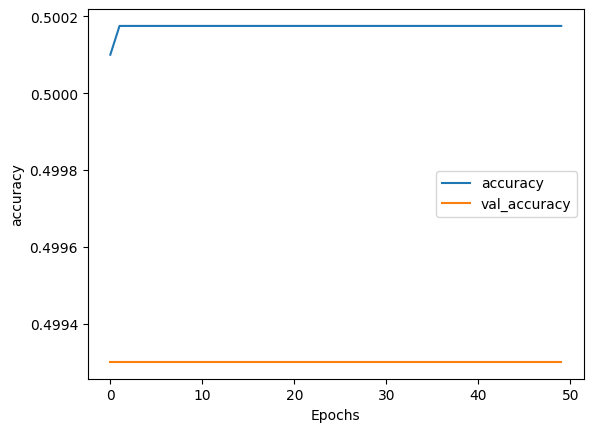

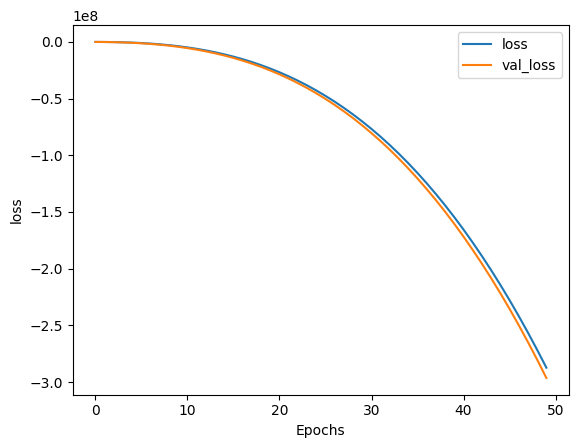

In [79]:
import matplotlib.pyplot as plt
def plot_graphs(history, string):
    plt.plot(history.history[string])
    plt.plot(history.history['val_'+string])
    plt.xlabel("Epochs")
    plt.ylabel(string)
    plt.legend([string, 'val_'+string])
    plt.show()

plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

In [80]:
# Get final evaluation
loss, accuracy = model.evaluate(test_padded, test_labels_sequences, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Test Loss: -296409792.0000
Test Accuracy: 0.4993


In [81]:
df['review'][0]

"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fa

In [82]:
txt = [df['review'][0]]

seq = sentences_tokenizer.texts_to_sequences(txt)
padded = pad_sequences(seq, maxlen=max_length)
pred = model.predict(padded)
labels = ['positive', 'negative']

print(pred)
print(np.argmax(pred))
print(labels[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
[[1.]]
0
positive


In [83]:
txt = [df['review'][0]]

seq = sentences_tokenizer.texts_to_sequences(txt)
padded = pad_sequences(seq, maxlen=max_length)
pred = model.predict(padded)
labels = ['business', 'entertainment', 'politics', 'sport', 'tech']

print(pred)
print(np.argmax(pred))
print(labels[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
[[1.]]
0
business


#### Hypertuning with Keras Tuner


In [31]:
!pip install keras_tuner

Defaulting to user installation because normal site-packages is not writeable


In [32]:
import tensorflow as tf
from tensorflow import keras
from keras_tuner import RandomSearch

# Define model builder function
def model_builder(hp):
    model = tf.keras.Sequential()

    # Embedding layer
    dim = hp.Choice('embedding_dim', values=[16, 32, 64, 128])
    model.add(tf.keras.layers.Embedding(vpcap_size, dim))

    # Pooling
    model.add(tf.keras.layers.GlobalAveragePooling1D())

    # First Dense layer
    units = hp.Int('dense_units', min_value=16, max_value=128, step=16)
    model.add(tf.keras.layers.Dense(units, activation='relu'))

    # Optional Dropout
    dropout_rate = hp.Float('dropout_rate', min_value=0.0, max_value=0.5, step=0.1)
    model.add(tf.keras.layers.Dropout(dropout_rate))

    # Output layer
    model.add(tf.keras.layers.Dense(6, activation='softmax'))

    # Optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    optimizer = tf.keras.optimizers.Adam(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    return model


In [33]:
tuner = RandomSearch(
    model_builder,
    objective='val_accuracy',
    max_trials=10,  # Try 10 different combinations
    executions_per_trial=2,  # Train each trial model twice for robustness
    directory='my_dir',
    project_name='text_classification_tuning'
)

# Early stopping
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)

# Search for best hyperparameters
tuner.search(train_padded, train_labels_sequences, 
             epochs=20, 
             validation_data=(test_padded, test_labels_sequences),
             callbacks=[stop_early], 
             verbose=2)


Reloading Tuner from my_dir\text_classification_tuning\tuner0.json


In [34]:
# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# Build and train the best model
model = tuner.hypermodel.build(best_hps)

history = model.fit(train_padded, train_labels_sequences, 
                    epochs=50, 
                    validation_data=(test_padded, test_labels_sequences), 
                    verbose=2)


Epoch 1/50
56/56 - 1s - 20ms/step - accuracy: 0.2702 - loss: 1.6431 - val_accuracy: 0.3820 - val_loss: 1.5342
Epoch 2/50
56/56 - 0s - 3ms/step - accuracy: 0.5685 - loss: 1.4401 - val_accuracy: 0.5640 - val_loss: 1.3288
Epoch 3/50
56/56 - 0s - 3ms/step - accuracy: 0.7573 - loss: 1.1715 - val_accuracy: 0.8022 - val_loss: 1.0308
Epoch 4/50
56/56 - 0s - 3ms/step - accuracy: 0.8646 - loss: 0.8507 - val_accuracy: 0.8674 - val_loss: 0.7509
Epoch 5/50
56/56 - 0s - 3ms/step - accuracy: 0.8983 - loss: 0.5806 - val_accuracy: 0.9056 - val_loss: 0.5238
Epoch 6/50
56/56 - 0s - 2ms/step - accuracy: 0.9331 - loss: 0.3978 - val_accuracy: 0.9213 - val_loss: 0.3867
Epoch 7/50
56/56 - 0s - 2ms/step - accuracy: 0.9483 - loss: 0.2853 - val_accuracy: 0.9169 - val_loss: 0.3227
Epoch 8/50
56/56 - 0s - 2ms/step - accuracy: 0.9567 - loss: 0.2188 - val_accuracy: 0.9348 - val_loss: 0.2623
Epoch 9/50
56/56 - 0s - 2ms/step - accuracy: 0.9685 - loss: 0.1755 - val_accuracy: 0.9303 - val_loss: 0.2363
Epoch 10/50
56/56 

In [36]:
# 📊 Get final evaluation
# Build the best model with best hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hps)

# Re-train
best_model.fit(train_padded, train_labels_sequences, 
          epochs=50, 
          validation_data=(test_padded, test_labels_sequences), 
          verbose=2)

# Final evaluation
loss, accuracy = best_model.evaluate(test_padded, test_labels_sequences, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")


Epoch 1/50
56/56 - 1s - 18ms/step - accuracy: 0.2938 - loss: 1.6499 - val_accuracy: 0.4427 - val_loss: 1.5473
Epoch 2/50
56/56 - 0s - 3ms/step - accuracy: 0.4758 - loss: 1.4595 - val_accuracy: 0.6607 - val_loss: 1.3594
Epoch 3/50
56/56 - 0s - 2ms/step - accuracy: 0.6792 - loss: 1.2062 - val_accuracy: 0.8090 - val_loss: 1.0771
Epoch 4/50
56/56 - 0s - 2ms/step - accuracy: 0.8483 - loss: 0.8629 - val_accuracy: 0.8562 - val_loss: 0.7487
Epoch 5/50
56/56 - 0s - 2ms/step - accuracy: 0.9090 - loss: 0.5692 - val_accuracy: 0.9034 - val_loss: 0.5260
Epoch 6/50
56/56 - 0s - 2ms/step - accuracy: 0.9404 - loss: 0.3757 - val_accuracy: 0.9303 - val_loss: 0.3792
Epoch 7/50
56/56 - 0s - 2ms/step - accuracy: 0.9579 - loss: 0.2658 - val_accuracy: 0.9393 - val_loss: 0.2998
Epoch 8/50
56/56 - 0s - 2ms/step - accuracy: 0.9652 - loss: 0.2028 - val_accuracy: 0.9393 - val_loss: 0.2519
Epoch 9/50
56/56 - 0s - 2ms/step - accuracy: 0.9747 - loss: 0.1602 - val_accuracy: 0.9393 - val_loss: 0.2503
Epoch 10/50
56/56 

In [81]:
txt = ["blair prepares to name poll date tony blair is likely to name 5 may as election"]

seq = sentences_tokenizer.texts_to_sequences(txt)
padded = pad_sequences(seq, maxlen=max_length)
pred = best_model.predict(padded)
labels = ['business', 'entertainment', 'politics', 'sport', 'tech']

print(pred)
print(np.argmax(pred))
print(labels[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[[1.1503725e-09 3.9712414e-01 1.8065587e-02 5.8477044e-01 3.9785413e-05
  6.2901168e-14]]
3
sport


In [89]:
txt = ["Money business"]

seq = sentences_tokenizer.texts_to_sequences(txt)
padded = pad_sequences(seq, maxlen=max_length)
pred = best_model.predict(padded)
labels = ['business', 'entertainment', 'politics', 'sport', 'tech']

print(pred)
print(np.argmax(pred))
print(labels[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
[[3.5643535e-10 9.3744892e-01 3.4480747e-02 2.8058428e-02 1.1869254e-05
  1.2199438e-14]]
1
entertainment


In [87]:
txt = [df['text'][2]]

seq = sentences_tokenizer.texts_to_sequences(txt)
padded = pad_sequences(seq, maxlen=max_length)
pred = best_model.predict(padded)
labels = ['business', 'entertainment', 'politics', 'sport', 'tech']

print(pred)
print(np.argmax(pred))
print(labels[np.argmax(pred)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
[[5.6315844e-08 9.7215241e-01 6.7346050e-06 3.5253641e-05 6.3009531e-05
  2.7742535e-02]]
1
entertainment


In [86]:
df

,category,text,char_count
0,tech,tv future in the hands of viewers with home th...,4333
1,business,worldcom boss left books alone former worldc...,1842
2,sport,tigers wary of farrell gamble leicester say ...,1342
3,sport,yeading face newcastle in fa cup premiership s...,2176
4,entertainment,ocean s twelve raids box office ocean s twelve...,1579
...,...,...,...
2220,business,cars pull down us retail figures us retail sal...,1745
2221,politics,kilroy unveils immigration policy ex-chatshow ...,955
2222,entertainment,rem announce new glasgow concert us band rem h...,1648
2223,politics,how political squabbles snowball it s become c...,4684
